In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report

In [3]:
# Carga del conjunto de datos directamente desde el repositorio remoto de GitHub en formato RAW
url = 'https://raw.githubusercontent.com/JUANPIS008/datasets/main/credit_card_fraud.csv'
df = pd.read_csv(url)

# Inspección de la estructura general del DataFrame y tipos de datos
print("Información general del Dataset")
df.info()
# Resumen estadístico descriptivo de las 30 variables del sistema
print("\nResumen Estadístico Descriptivo")
print(df.describe())

Información general del Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Transaction Date and Time                8000 non-null   object 
 1   Transaction Amount                       8000 non-null   float64
 2   Cardholder Name                          8000 non-null   object 
 3   Card Number (Hashed or Encrypted)        8000 non-null   object 
 4   Merchant Name                            8000 non-null   object 
 5   Merchant Category Code (MCC)             8000 non-null   int64  
 6   Transaction Location (City or ZIP Code)  8000 non-null   object 
 7   Transaction Currency                     8000 non-null   object 
 8   Card Type                                8000 non-null   object 
 9   Card Expiration Date                     8000 non-null   object 
 10  CVV Code (Hashed

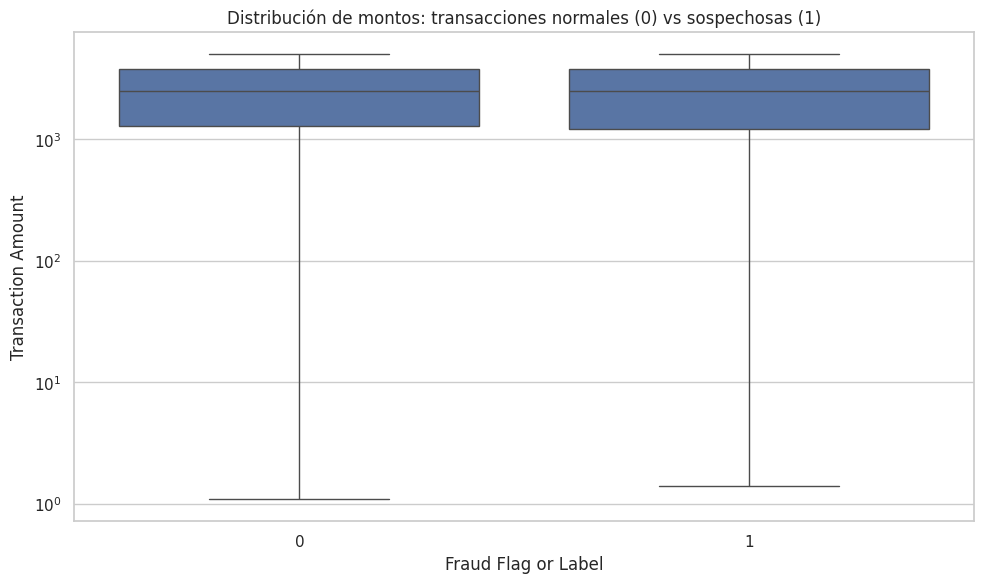

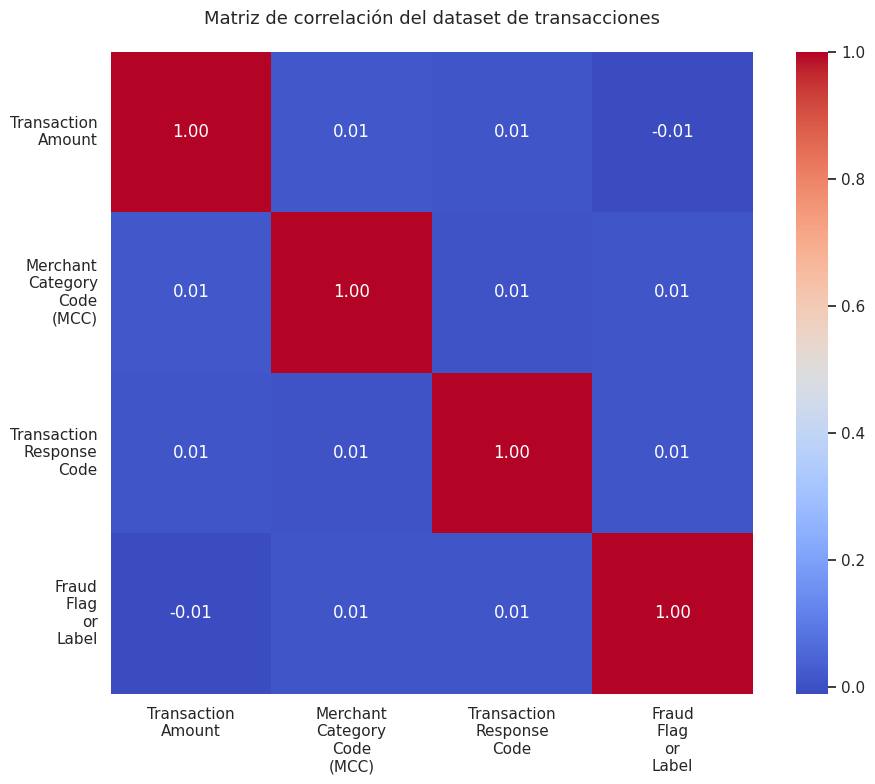

In [4]:
# Configuración del estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Visualización de la distribución de la variable Amount para fraude vs normal
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fraud Flag or Label', y='Transaction Amount', data=df)
plt.title('Distribución de montos: transacciones normales (0) vs sospechosas (1)')
plt.yscale('log')
plt.tight_layout()
plt.show()

# Matriz de correlación lineal entre las variables numéricas principales
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include="number").corr()

# Creamos etiquetas con saltos de línea reemplazando los espacios por '\n'
# Esto transforma por ejemplo 'Transaction Amount' en 'Transaction\nAmount'
labels_con_salto = [col.replace(' ', '\n') for col in correlation_matrix.columns]

# Creamos el mapa de calor guardando la referencia en la variable 'ax'
ax = sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f", square=True)

# Asignamos las nuevas etiquetas con salto de línea a ambos ejes y aumentamos el tamaño de la letra
ax.set_xticklabels(labels_con_salto, rotation=0, ha='center', fontsize=11)
ax.set_yticklabels(labels_con_salto, rotation=0, va='center', fontsize=11)

plt.title('Matriz de correlación del dataset de transacciones', pad=20, fontsize=13)

# Ajuste automático de márgenes para asegurar que todo el texto quepa perfectamente
plt.tight_layout()

plt.show()

In [5]:
#Eliminar valores nulos del dataset para evitar errores en el escalado
# Calcular la cantidad absoluta de celdas nulas en toda la matriz de datos
total_nulos = df.isnull().sum().sum()
print(f"Cantidad total de valores nulos detectados antes de la limpieza: {total_nulos}")

# Ejecución de la remoción condicional en caso de detectar datos corruptos o faltantes
if total_nulos > 0:
    df = df.dropna()
    print("Acción: Se han eliminado exitosamente los registros con valores nulos.")
else:
    print("Acción: El dataset está completamente limpio; no requiere remoción de filas.")


Cantidad total de valores nulos detectados antes de la limpieza: 6053
Acción: Se han eliminado exitosamente los registros con valores nulos.


In [6]:
# Renombrar las columnas comerciales originales a variables estándar para el modelado
df = df.rename(columns={
    'Transaction Amount': 'Amount',
    'Transaction Date and Time': 'Time'
})

print("\nEstructura nominal de control verificada (Primeros 5 registros):")
print(df[['Time', 'Amount']].head())

# Convertir el texto de fecha y hora a objetos datetime, extraer enteros Unix y pasar a segundos
df['Time'] = pd.to_datetime(df['Time']).astype('int64') // 10**9

# Inicializar el transformador estadístico de scikit-learn
escalador = StandardScaler()

# Ajustar el escalador y transformar simultáneamente las columnas Time y Amount
df[['Amount', 'Time']] = escalador.fit_transform(df[['Amount', 'Time']])



Estructura nominal de control verificada (Primeros 5 registros):
                   Time   Amount
5   2020-01-14 21:03:12  3341.97
7   2022-05-08 10:49:06  1117.52
8   2022-08-19 23:40:26   388.16
9   2022-09-10 05:59:18  4514.53
10  2020-04-19 15:18:20  1805.22


In [7]:
# Verificación de los resultados del preprocesamiento y escalado
print("\nValores estandarizados después del preprocesamiento (Primeros 5 registros):")
print(df[['Time', 'Amount']].head())

# Comprobación de los axiomas requeridos por la rúbrica (Media cercana a 0 y Desviación igual a 1)
print("\nComprobación Estadística del Escalado")
print(f"Media aritmética calculada para la columna 'Time' : {df['Time'].mean():.2f}")
print(f"Desviación estándar calculada para la columna 'Time': {df['Time'].std():.2f}")
print(f"Media aritmética calculada para la columna 'Amount' : {df['Amount'].mean():.2f}")
print(f"Desviación estándar calculada para la columna 'Amount': {df['Amount'].std():.2f}")


Valores estandarizados después del preprocesamiento (Primeros 5 registros):
        Time    Amount
5  -1.724857  0.615079
7   0.431078 -0.911940
8   0.695373 -1.412624
9   0.749651  1.420007
10 -1.480410 -0.439855

Comprobación Estadística del Escalado
Media aritmética calculada para la columna 'Time' : -0.00
Desviación estándar calculada para la columna 'Time': 1.00
Media aritmética calculada para la columna 'Amount' : -0.00
Desviación estándar calculada para la columna 'Amount': 1.00


In [8]:
# Separacion de caracteristicas (X) y variable objetivo (y)

# Crear la matriz X eliminando la columna objetivo 'Fraud Flag or Label'
X = df.drop(columns=['Fraud Flag or Label'])

# Crear el vector y aislando la columna objetivo 'Fraud Flag or Label'
y = df['Fraud Flag or Label']

# La columna objetivo correcta en este dataset es 'Fraud Flag or Label'
y = df['Fraud Flag or Label']

In [9]:
# Division del dataset 80% entrenamiento 20%prueba
# Ejecutar la partición probabilística de los datos con semilla fija y estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

In [10]:
# Calidad y control de las dimensiones de las particiones de entrenamiento y prueba
print("Verificación de dimensiones de las particiones")
print(f"Conjunto de Características de Entrenamiento (X_train): {X_train.shape}")
print(f"Conjunto de Etiquetas de Entrenamiento (y_train): {y_train.shape}")
print(f"Conjunto de Características de Prueba (X_test): {X_test.shape}")
print(f"Conjunto de Etiquetas de Prueba (y_test): {y_test.shape}")

print("\nValidación del Balanceo de Clases (Estratificación)".center)
print("Proporción de clases en el conjunto de entrenamiento (y_train):")
print(y_train.value_counts(normalize=True))

print("\nProporción de clases en el conjunto de prueba (y_test):")
print(y_test.value_counts(normalize=True))

Verificación de dimensiones de las particiones
Conjunto de Características de Entrenamiento (X_train): (2391, 19)
Conjunto de Etiquetas de Entrenamiento (y_train): (2391,)
Conjunto de Características de Prueba (X_test): (598, 19)
Conjunto de Etiquetas de Prueba (y_test): (598,)
<built-in method center of str object at 0x7c023bbfd530>
Proporción de clases en el conjunto de entrenamiento (y_train):
Fraud Flag or Label
1    0.508574
0    0.491426
Name: proportion, dtype: float64

Proporción de clases en el conjunto de prueba (y_test):
Fraud Flag or Label
1    0.508361
0    0.491639
Name: proportion, dtype: float64


In [11]:
# Filtrado de caracteristicas exclusivas de transacciones normales
# X_train para conservar únicamente las filas donde la etiqueta en y_train sea 0 (Normal)
X_train_normal = X_train[y_train == 0]

print("Verificación del filtro de entrenamiento")
print(f"Dimensiones de la matriz original de entrenamiento (X_train)  : {X_train.shape}")
print(f"Dimensiones de la matriz filtrada de datos normales (X_train_normal): {X_train_normal.shape}")

# Configurar el modelo con 2 componentes para segmentar la normalidad y semilla de reproducibilidad
gmm_model = GaussianMixture(
    n_components=2, 
    random_state=42
)

#Entrenamiento y ajsute exclusivo del modelo GMM
print("\nIniciando el proceso de ajuste del modelo GMM...")
# Ajustar el modelo únicamente con los vectores de características normales
# Seleccionar únicamente columnas numéricas antes de ajustar el GMM
X_train_normal_numeric = X_train_normal.select_dtypes(include=['number'])
gmm_model.fit(X_train_normal_numeric)
print("¡Entrenamiento del modelo GMM completado con éxito!")

# Aproximación del modelo GMM
print("\nMétricas de Control del Modelo Ajustado")
print(f"¿El algoritmo logró converger exitosamente?: {gmm_model.converged_}")
print(f"Número de iteraciones requeridas para converger: {gmm_model.n_iter_}")
print(f"Log-likelihood promedio del sistema ajustado   : {gmm_model.lower_bound_:.4f}")

Verificación del filtro de entrenamiento
Dimensiones de la matriz original de entrenamiento (X_train)  : (2391, 19)
Dimensiones de la matriz filtrada de datos normales (X_train_normal): (1175, 19)

Iniciando el proceso de ajuste del modelo GMM...
¡Entrenamiento del modelo GMM completado con éxito!

Métricas de Control del Modelo Ajustado
¿El algoritmo logró converger exitosamente?: True
Número de iteraciones requeridas para converger: 3
Log-likelihood promedio del sistema ajustado   : -15.0408


In [12]:
#Seleccion de las varianles numericas
# Asegurar que el conjunto de prueba tenga solo las variables numéricas escaladas
X_test_numeric = X_test.select_dtypes(include=['number'])

print("Preparación del Conjunto de Prueba")
print(f"Dimensiones de la matriz numérica para evaluación (X_test_numeric): {X_test_numeric.shape}")

# Calcular el logaritmo de la densidad de probabilidad para cada transacción de prueba
log_scores = gmm_model.score_samples(X_test_numeric)

# Visualizar un resumen estadístico básico de los scores obtenidos
print("\nDiagnóstico de puntuaciones de densidad logarito")
print(f"Puntuación máxima de normalidad detectada: {log_scores.max():.4f}")
print(f"Puntuación mínima de densidad (Caso más extraño): {log_scores.min():.4f}")
print(f"Puntuación promedio del set de prueba : {log_scores.mean():.4f}")

# Definir la tasa estimada de contaminación del negocio (Ejemplo: 5% de anomalías)
porcentaje_anomalias_estimado = 5

# Calcular el valor límite matemático usando el percentil inferior
threshold_limite = np.percentile(log_scores, porcentaje_anomalias_estimado)

print("\nConfiguración del umbral estadístico")
print(f"Porcentaje de registros a marcar como anomalías: {porcentaje_anomalias_estimado}%")
print(f"Valor del umbral calculado (Cualquier score menor a este será fraude): {threshold_limite:.4f}")

# Clasificacion binaria
# Crear un vector lleno de ceros (Normal) con la misma longitud que los datos de prueba
y_pred_gmm = np.zeros(len(log_scores), dtype=int)

# Marcar como 1 (Anomalía/Fraude) aquellos registros cuyo score esté por debajo del umbral
y_pred_gmm[log_scores < threshold_limite] = 1

# Crear un DataFrame temporal de control para resumir los hallazgos en la consola
resumen_alertas = pd.Series(y_pred_gmm).value_counts()

print("\nConteo final de predicciones del modelo GMM")
print(f"Transacciones clasificadas como NORMALES (Clase 0): {resumen_alertas.get(0, 0)}")
print(f"Transacciones marcadas como ANOMALÍAS/FRAUDE (Clase 1): {resumen_alertas.get(1, 0)}")

Preparación del Conjunto de Prueba
Dimensiones de la matriz numérica para evaluación (X_test_numeric): (598, 4)

Diagnóstico de puntuaciones de densidad logarito
Puntuación máxima de normalidad detectada: -13.1330
Puntuación mínima de densidad (Caso más extraño): -18.2919
Puntuación promedio del set de prueba : -15.0257

Configuración del umbral estadístico
Porcentaje de registros a marcar como anomalías: 5%
Valor del umbral calculado (Cualquier score menor a este será fraude): -16.4611

Conteo final de predicciones del modelo GMM
Transacciones clasificadas como NORMALES (Clase 0): 568
Transacciones marcadas como ANOMALÍAS/FRAUDE (Clase 1): 30


Evaluación geométrica del agrupamiento (GMM)
Calculando el Silhouette Score (esto puede tomar unos segundos)...
Coeficiente de silueta obtenido: 0.1591
Resultado: RECHAZADO. 0.1591 está por debajo de 0.4, requiere ajustar el umbral.


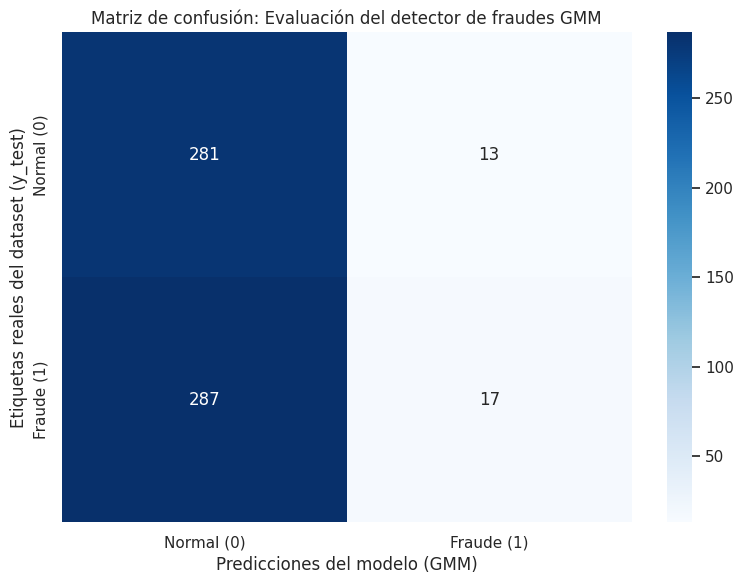


Reporte detallado de métricas de clasificación
              precision    recall  f1-score   support

  Normal (0)       0.49      0.96      0.65       294
  Fraude (1)       0.57      0.06      0.10       304

    accuracy                           0.50       598
   macro avg       0.53      0.51      0.38       598
weighted avg       0.53      0.50      0.37       598



In [13]:
#Calculo e interpretación
print("Evaluación geométrica del agrupamiento (GMM)")
print("Calculando el Silhouette Score (esto puede tomar unos segundos)...")

# Calcular la silueta sobre el conjunto de prueba numérico escalado
# Se incluye sample_size para optimizar el rendimiento computacional en RAM
sil_score = silhouette_score(
    X_test_numeric, 
    y_pred_gmm, 
    metric='euclidean', 
    sample_size=10000, 
    random_state=42
)

print(f"Coeficiente de silueta obtenido: {sil_score:.4f}")

# Validar el criterio de aceptación requerido por la rúbrica del problema
if sil_score > 0.4:
    print(f"Resultado: ¡ACEPTABLE! {sil_score:.4f} supera el umbral mínimo de 0.4.")
else:
    print(f"Resultado: RECHAZADO. {sil_score:.4f} está por debajo de 0.4, requiere ajustar el umbral.")

# Calcular la matriz contrastando las etiquetas reales vs las predicciones del GMM
matriz_confusion = confusion_matrix(y_test, y_pred_gmm)

#Vizualización de la matriz
plt.figure(figsize=(8, 6))
# mapa de calor con anotaciones enteras y paleta azul
sns.heatmap(
    matriz_confusion, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Normal (0)', 'Fraude (1)'], 
    yticklabels=['Normal (0)', 'Fraude (1)']
)

plt.title('Matriz de confusión: Evaluación del detector de fraudes GMM')
plt.xlabel('Predicciones del modelo (GMM)')
plt.ylabel('Etiquetas reales del dataset (y_test)')
plt.tight_layout()
plt.show()

# Reporte estadistio 
print("\nReporte detallado de métricas de clasificación")
# Generar reporte escrito de Precisión, Recall y F1-Score para complementar la tarea
print(classification_report(y_test, y_pred_gmm, target_names=['Normal (0)', 'Fraude (1)']))

In [ ]:
# Crearcion del directorio destino 
# Definir la ruta de la carpeta donde se almacenarán los artefactos binarios
directorio_modelos = os.path.join('..', 'models')

# Verificar la existencia de la carpeta; si no existe, se crea estructuralmente
if not os.path.exists(directorio_modelos):
    os.makedirs(directorio_modelos)
    print(f"Directorio creado exitosamente: '{directorio_modelos}/'")
else:
    print(f"El directorio '{directorio_modelos}/' ya existe. Procediendo al guardado...")

# Definir los nombres de los archivos físicos para el escalador y el modelo
ruta_escalador = os.path.join(directorio_modelos, 'scaler.pkl')
ruta_modelo_gmm = os.path.join(directorio_modelos, 'modelo_gmm.pkl')

print("\nIniciando proceso de serialización en disco")

# Persistir el transformador estadístico (esencial para normalizar datos nuevos en la web)
# Se utiliza la variable 'escalador' instanciada en tus celdas previas
joblib.dump(escalador, ruta_escalador)
print(f"Escalador guardado correctamente en: '{ruta_escalador}'")

# Persistir el modelo predictivo ajustado de mezclas gaussianas
# Se utiliza la variable 'gmm_model' entrenada en tus celdas previas
joblib.dump(gmm_model, ruta_modelo_gmm)
print(f"Modelo GMM guardado correctamente en: '{ruta_modelo_gmm}'")

# Revision de la integridad y el control de los archivos
print("\nVerificación de persistencia en el sistema de archivos")
# Calcular el peso en disco para comprobar la correcta escritura del flujo de bytes
tamano_scaler = os.path.getsize(ruta_escalador) / 1024
tamano_gmm = os.path.getsize(ruta_modelo_gmm) / 1024

print(f"Archivo '{os.path.basename(ruta_escalador)}' verificado. Tamaño en disco: {tamano_scaler:.2f} KB")
print(f"Archivo '{os.path.basename(ruta_modelo_gmm)}' verificado. Tamaño en disco: {tamano_gmm:.2f} KB")
print("\nFase de serialización completada. Listos para ser consumidos por la aplicación web.")

El directorio '../models/' ya existe. Procediendo al guardado...

Iniciando proceso de serialización en disco
Escalador guardado correctamente en: '../models/scaler.pkl'
Modelo GMM guardado correctamente en: '../models/modelo_gmm.pkl'

Verificación de persistencia en el sistema de archivos
Archivo 'scaler.pkl' verificado. Tamaño en disco: 0.91 KB
Archivo 'modelo_gmm.pkl' verificado. Tamaño en disco: 2.10 KB

Fase de serialización completada. Listos para ser consumidos por la aplicación web.
